In [1]:
%load_ext autoreload
import torch
import numpy as np
import l4casadi as l4c
import casadi as cas
from models import *
from utils.data_loader import *
import utils.utilities as utilities
torch.backends.mkldnn.flags.rnn = False
torch.backends.mkldnn.enabled = False

Loading data and models

In [2]:
%autoreload 2
parent = ''
data_dict,mu_dict,nodes,_ = load_raw_data(parent+'data\\raw_data\\', filter3D=pd.concat([pd.read_csv(parent+'data\\nodes\\c1.csv'),pd.read_csv(parent+'data\\nodes\\c2.csv'),pd.read_csv(parent+'data\\nodes\\sus.csv')]))    
manager = DatasetManager(
    data_dict=data_dict, 
    mu_dict=mu_dict, 
    train_share=0.8, 
    valid_share=0.1, 
    POD_dim=10, 
    seq_len=10,
    )
train_dataset, valid_dataset, test_dataset = manager.make_SHRED_datasets(ykey='POD_coefs')

c:\Users\abhyu\Documents\SINTEF\clean_start\utils\utilities.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.stdev = torch.tensor(np.sqrt(self.var), dtype =torch.float32)


In [3]:
shred = SHRED(
   in_dim=train_dataset.X.shape[-1],
   out_dim=train_dataset.Y.shape[-1],
   batch_first=True,
   data_manager=manager,
   lstm_params= {
                  'seq_len': 10, 
                  'n_layers': 2,
                  'hidden_dim': 64,
               },
   sdn_params = {
                  'inner_layers': [200,100],
                  'dropout': [True, 0.1],
                  'batch_norm': [False],
               },
            )
weights = torch.load('shred.json', weights_only=True)
shred.load_state_dict(weights)
shred.eval()
train_dataset_forecaster, valid_dataset_forecaster, test_dataset_forecaster = manager.make_FORECASTER_datasets(shred)

In [4]:
forecaster = SHREDForecaster(
    u_dim=train_dataset_forecaster.X.shape[-1], 
    out_dim=train_dataset_forecaster.Y.shape[-1], 
    lstm_params = {
                'seq_len': 10, 
                'n_layers': 1,
                'hidden_dim': 64,
                },
    batch_first=True,
    data_manager=None,
)
forecaster_weights = torch.load('forecaster_weights.json')
forecaster.load_state_dict(forecaster_weights)
forecaster.eval()

SHREDForecaster(
  (lstm): LSTM(
    (lstm): LSTM(67, 64, batch_first=True)
  )
  (proj): Linear(in_features=64, out_features=64, bias=True)
)

In [5]:
c1_picker = torch.tensor(np.loadtxt('data/core_regions/c1_picker.txt'), dtype=torch.float32)
c2_picker = torch.tensor(np.loadtxt('data/core_regions/c2_picker.txt'), dtype=torch.float32)
sus_picker = torch.tensor(np.loadtxt('data/core_regions/sus_picker.txt'), dtype=torch.float32)

# n2 = 100  # number of rows to keep
# torch.manual_seed(42)  # Any integer seed
# c1_idx  = torch.randperm(c1_picker.shape[0])[:n2]
# c2_idx  = torch.randperm(c2_picker.shape[0])[:n2]
# sus_idx = torch.randperm(sus_picker.shape[0])[:n2]
# c1_picker  = c1_picker[c1_idx]
# c2_picker  = c2_picker[c2_idx]
# sus_picker = sus_picker[sus_idx]
picker = torch.cat([c1_picker, c2_picker, -1*sus_picker])

In [6]:
seq_len = train_dataset_forecaster.X.shape[1]
out_dim = train_dataset_forecaster.Y.shape[-1]
u_dim   = train_dataset_forecaster.X.shape[-1] - out_dim
f = 5                             
c1_target = 2000
c2_target = 2000
sus_target = -2500

target = torch.cat([c1_target*torch.ones((c1_picker.shape[0],1)), c2_target*torch.ones((c2_picker.shape[0],1)), sus_target*torch.ones((sus_picker.shape[0],1))]).T
# target = torch.cat([target for _ in range(f)],dim=1).T

Setting equilibiurm point and loading linear controller (from linearized LQR files)

In [8]:
# Z_tilde = manager.Yscaler.inverse_transform(test_dataset.Y[30])
# np.savetxt('data/mpc_files/Z_tilde.txt', Z_tilde.detach())
u_tilde_prev = test_dataset_forecaster.X[30,:,:3]
x_tilde_prev = test_dataset_forecaster.X[30,:,3:]
np.savetxt('data/mpc_files/u_tilde_prev.txt', u_tilde_prev.detach())
np.savetxt('data/mpc_files/x_tilde_prev.txt', x_tilde_prev.detach())
K_f = torch.tensor(np.loadtxt('data/mpc_files/Kmatrix.txt'),dtype=torch.float32)
P = torch.tensor(np.loadtxt('data/mpc_files/Pmatrix.txt'),dtype=torch.float32)

Building/loading l4c model

In [ ]:
cost = CostWrapperMultipleShooting(
    shred=shred, 
    f=f, 
    u_dim = u_dim,
    target=target, 
    picker=picker, 
    P=P,
    x_tilde=x_tilde_prev[-1,],
    u_tilde=u_tilde_prev[-1,]
    )
cooling = torch.tensor(np.loadtxt('data/cooling_avg.txt'),dtype=torch.float32)
u_prev = test_dataset_forecaster.X[0][:-1,:3]
x_prev = test_dataset_forecaster.X[0][:,3:]
p_plan = 0.9*torch.ones((f,1))
E_plan = utilities.integrate_series(manager.Pscaler.inverse_transform(p_plan))
C_plan = torch.tensor(cooling[:f],dtype=torch.float32).reshape(-1,1)
u_plan = torch.cat([p_plan, E_plan, C_plan], dim=1)

C:\Users\abhyu\AppData\Local\Temp\ipykernel_20692\278178470.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  C_plan = torch.tensor(cooling[:f],dtype=torch.float32).reshape(-1,1)


In [73]:
%autoreload 2
build_dir = '_multipleshootingl4c_alt_target_'
l4c_model = l4c.L4CasADi(cost, device='cpu', build_dir=build_dir, generate_jac_jac=False)
if build_dir in os.listdir():
    print('FOUND EXISTING l4casadi build. Loading...')
    l4c_model._built = True
    l4c_model._input_shape  = (f*out_dim + f*u_dim + 1, 1)
    l4c_model._output_shape = (1, 1)
else:
    print('No such directory, building new model...')

print('Defining the casadi function')
X_sym = cas.MX.sym('X', f*out_dim + f*u_dim + 1, 1)

y_sym = l4c_model(X_sym)
cost_sym = cas.Function('cost', [X_sym], [y_sym])
dcost_sym = cas.Function('grad_cost', [X_sym], [cas.gradient(cost_sym(X_sym), X_sym)])
print(cost_sym)


FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
cost:(i0[336])->(o0) MXFunction


In [176]:
%autoreload 2
build_dir = '_forecasterl4c_multi_'
forecaster_l4c = l4c.L4CasADi(forecaster, device='cpu', build_dir=build_dir, generate_jac_jac=False)
if build_dir in os.listdir():
    print('FOUND EXISTING l4casadi build. Loading...')
    forecaster_l4c._built = True
    forecaster_l4c._input_shape  = (seq_len, u_dim+out_dim)
    forecaster_l4c._output_shape = (1, out_dim)
else:
    print('No such directory, building new model...')

print('Defining the casadi function')
X_sym = cas.MX.sym('X', seq_len, u_dim+out_dim)
print(X_sym.shape)
y_sym = forecaster_l4c(X_sym)
print(y_sym.shape)

forecaster_sym = cas.Function('forecaster', [X_sym], [y_sym])
df = cas.Function('grad_forecaster', [X_sym], [cas.jacobian(forecaster_sym(X_sym), X_sym)])
print(forecaster_sym)

FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
(10, 67)
(1, 64)
forecaster:(i0[10x67])->(o0[1x64]) MXFunction


Testing l4c model

In [32]:
ux = np.zeros((u_dim*f + out_dim*f + 1,1))
ux_dm = cas.DM(ux)       # shape (N,1)

print("calling J...")
val = cost_sym(ux_dm)
print("cost_sym ok:", val)

calling J...
cost_sym ok: 0.248179


In [31]:
print("calling dJ...")
grad_val = dcost_sym(ux_dm)
print("dcost_sym ok:", grad_val)

calling dJ...
dcost_sym ok: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.116695, -0.0805561, -0.153632, 0.108055, 0.137821, -0.0208443, -0.137503, -0.0779634, -0.0228159, -0.0266602, 0.0425669, -0.0259896, 0.0740098, 0.129544, -0.0329759, -0.0239812, 0.136075, 0.0158376, 0.0111204, -0.206939, -0.134539, 0.0672094, 0.0408741, -0.0273153, -0.0242224, -0.063141, 0.135239, 0.0438552, 0.0747127, -0.0329636, 0.00678191, 0.269704, 0.0374557, 0.119394, -0.0625131, -0.0441687, 0.148592, -0.0338271, 0.0465022, 0.138966, 0.0222591, 0.00923154, -0.123604, -0.0229873, 0.00968526, -0.0177681, -0.0626448, 0.0679196, 0.0138513, -0.0518944, 0.17456, -0.01575, -0.045479, 0.0140227, 0.165838, -0.135708, 0.0153309, -0.16987, 0.0572787, -0.0156135, -0.21589, 0.0869635, -0.0435367, 0.22158, -0.116695, -0.0805561, -0.153632, 0.108055, 0.137821, -0.0208443, -0.137503, -0.0779634, -0.0228159, -0.0266602, 0.0425669, -0.0259896, 0.0740098, 0.129544, -0.0329759, -0.0239812, 0.136075, 0.0158376, 0.0111204, -0.

Setting up NLP problem

In [135]:
w = []      # decision variables
g = []      # constraints
lbg = []
ubg = []

#ADDING E_plan, C_plan, u_prev, x_prev, Vf_toggle to parameters
E_plan_list = [cas.MX.sym(f'E_{seq_len+j}', 1) for j in range(f)]
E_plan = cas.vertcat(*E_plan_list)
C_plan_list = [cas.MX.sym(f'C_{seq_len+j}', 1) for j in range(f)]
C_plan = cas.vertcat(*C_plan_list)
x_syms = [cas.MX.sym(f'x_{j}', out_dim) for j in range(seq_len)]
x_prev = cas.vertcat(*x_syms)
u_syms = [cas.MX.sym(f'u_{j}', u_dim) for j in range(seq_len-1)]
u_prev = cas.vertcat(*u_syms)
Vf_toggle = cas.MX.sym('Vf_toggle', 1)
print(u_prev.shape, x_prev.shape, E_plan.shape, C_plan.shape)
params = cas.vertcat(u_prev, x_prev, E_plan, C_plan, Vf_toggle) #parameters

#ADDING u_next, x_next to decision variables
for j in range(f):
    pj = cas.MX.sym(f'p_{seq_len-1+j}', 1)
    Ej,Cj = E_plan_list[j],C_plan_list[j]
    uj = cas.vertcat(pj,Ej,Cj)
    u_syms.append(uj)
    w.append(pj)
    
for j in range(f):
    xj = cas.MX.sym(f'x_{seq_len+j}', out_dim)
    x_syms.append(xj)
    w.append(xj)

#IMPOSING state dyanmics as equality constraints
for j in range(f):
    u_window = [_.reshape((1,-1)) for _ in u_syms[j:j+seq_len]]
    u_window = cas.vertcat(*u_window)
    x_window = [_.reshape((1,-1)) for _ in x_syms[j:j+seq_len]]
    x_window = cas.vertcat(*x_window)
    ux_prev = cas.horzcat(u_window,x_window)   #stitching together u_prev, x_prev into single list
    x_next = forecaster_sym(ux_prev).reshape((-1, 1))
    g.append(x_syms[seq_len + j] - x_next)
    lbg += [0]*out_dim# equality: 0 <= g <= 0
    ubg += [0]*out_dim# equality: 0 <= g <= 0

w = cas.vertcat(*w)
g = cas.vertcat(*g)

print(w)
print(params)
print(g)
nlp = {
    'f': cost_sym(cas.vertcat(w,params[(seq_len*out_dim) + (seq_len-1)*u_dim:])),#function   (cost_sym)
    'x': w,          #input      (u_next, x_next)
    'p':params,      #parameters (u_prev, x_prev)
    'g': g}          #constraints(dynamics)

opts = {
    'ipopt': {
        'max_iter': 100,
        'delta': 0.5,
        'bound_push': 1e-6,
        'bound_frac': 1e-6,
        'print_level': 1,
        'check_derivatives_for_naninf': 'yes',
        'hessian_approximation': 'limited-memory',  # avoid exact Hessian computation
    }
}
solver = cas.nlpsol('solver', 'ipopt', nlp, opts)
print(solver)

(27, 1) (640, 1) (5, 1) (5, 1)
vertcat(p_9, p_10, p_11, p_12, p_13, x_10, x_11, x_12, x_13, x_14)
vertcat(u_0, u_1, u_2, u_3, u_4, u_5, u_6, u_7, u_8, x_0, x_1, x_2, x_3, x_4, x_5, x_6, x_7, x_8, x_9, E_10, E_11, E_12, E_13, E_14, C_10, C_11, C_12, C_13, C_14, Vf_toggle)
@1=vertcat(p_9, E_10, C_10), @2=vertcat(p_10, E_11, C_11), @3=vertcat(p_11, E_12, C_12), @4=vertcat(p_12, E_13, C_13), vertcat((x_10-J(horzcat(horzcat(u_0, u_1, u_2, u_3, u_4, u_5, u_6, u_7, u_8, @1)', horzcat(x_0, x_1, x_2, x_3, x_4, x_5, x_6, x_7, x_8, x_9)')){0}'), (x_11-J(horzcat(horzcat(u_1, u_2, u_3, u_4, u_5, u_6, u_7, u_8, @1, @2)', horzcat(x_1, x_2, x_3, x_4, x_5, x_6, x_7, x_8, x_9, x_10)')){0}'), (x_12-J(horzcat(horzcat(u_2, u_3, u_4, u_5, u_6, u_7, u_8, @1, @2, @3)', horzcat(x_2, x_3, x_4, x_5, x_6, x_7, x_8, x_9, x_10, x_11)')){0}'), (x_13-J(horzcat(horzcat(u_3, u_4, u_5, u_6, u_7, u_8, @1, @2, @3, @4)', horzcat(x_3, x_4, x_5, x_6, x_7, x_8, x_9, x_10, x_11, x_12)')){0}'), (x_14-J(horzcat(horzcat(u_4, u_5,

Multiple shooting MPC routine

In [142]:
u_prev = test_dataset_forecaster.X[0,:-1,:3]
x_prev = test_dataset_forecaster.X[0][:,3:]
p_plan = manager.Pscaler.inverse_transform(0.9*torch.ones((f,1)))
E_plan = utilities.integrate_series(p_plan)/1000 #kWh to MWh
C_plan = cooling[:f].reshape(-1,1)
u_plan = torch.cat([p_plan, E_plan, C_plan], dim=1)


In [ ]:
def compute_MPC_multiple_shooting(solver, shred, f, n_steps, u_prev, x_prev, u_tilde, x_tilde, K_f, cooling_plan, lbg = None, ubg = None, plotting=False, seq_len=seq_len, u0 = None, x0 = None, Vf_toggle = 1):    
    Vf_toggle = torch.tensor(1,dtype=torch.float32).reshape(1,1)
    lbg = [0]*(out_dim*f) if lbg is None else lbg# equality: 0 <= g <= 0
    ubg = [0]*(out_dim*f) if ubg is None else ubg# equality: 0 <= g <= 0

    def update_window(prev, new, des_len = seq_len):
        if not type(prev) == type(new):
            raise TypeError('both inputs must have the same type')

        if prev.shape[0] == des_len - 1:
            l = 0
        elif prev.shape[0] == des_len:
            l = 1
        else:
            raise


        if type(prev) == torch.Tensor:
            return torch.cat([prev[l:].contiguous(), new.reshape(1,-1)])
        elif type(prev) == np.ndarray:
            return np.vstack([prev[l:].copy(), new.reshape(1,-1)])
        else:
            raise TypeError(f'type(prev)={type(prev)} is not support')
        
    if u0 is None:
        raise NotImplementedError('Need to implement making u0 with the terminal controller')
    elif (u0.max() > 1.0) or (u0.min() < 0.0):
        print('Warm start is unscaled, scaling...')
        u0_s = manager.Uscaler.transform(u0)
    else:
        u0_s = u0
        
    if x0 is None:
        x_plan = []
        x_prev__ = x_prev
        u_prev__ = u_prev
        for uj in u0_s:
            u_prev__ = update_window(u_prev__, uj)
            ux_prev = torch.cat([u_prev__,x_prev__],dim=1)
            xj = forecaster(ux_prev)
            x_prev__ = update_window(x_prev__,xj)
            x_plan.append(xj)
        x0 = torch.cat(x_plan)
        
    power_plan_opt = []
    latent_pred = []
    traj_pred = []

    u_tilde = torch.tensor(u_tilde, dtype=torch.float32)
    x_tilde = torch.tensor(x_tilde, dtype=torch.float32)
    lbx = np.vstack([np.zeros((f,1)),-1*np.ones_like(x0.detach()).reshape(-1,1)])#,dim=1)
    ubx = np.vstack([np.ones((f,1)),1*np.ones_like(x0.detach()).reshape(-1,1)])#,dim=1)

    
    if (x0.max() > 1.0) or (x0.min() < -1.0):
        raise ValueError(f'{x0.min()}, {x0.max()}')

    for k in range(n_steps):
        print(f'----------{k+1}----------')
        #UNSCALED
        if u_prev[-1,1] >= 1:
            print(f'MAX ENERGY REACHED AT STEP {k}')
            break
        u_unscaled = manager.Uscaler.inverse_transform(u_prev)
        E_now = u_unscaled[-1,1]

        #SCALED
        p0_s = u0_s[:,0].reshape(-1,1).detach() #scaled power plan guess
        E0_s = u0_s[:,1].reshape(-1,1).detach() #scaled E_plan guess
        C0_s = u0_s[:,2].reshape(-1,1).detach()#scaled C_plan guess
        print(p0_s.shape, E0_s.shape, C0_s.shape, u_prev.shape, )
        param_s = torch.cat([
            u_prev.flatten().reshape(-1,1),
            x_prev.flatten().reshape(-1,1), 
            E0_s, 
            C0_s,
            Vf_toggle
            ]).detach().numpy() #scaled params

        w0_s = torch.cat([p0_s,x0.reshape(-1,1).detach()]).numpy()

        sol = solver(
            x0=w0_s, 
            p=param_s,
            lbg=lbg, 
            ubg=ubg, 
            lbx=lbx, 
            ubx=ubx)

        w_opt_s = np.array(sol['x']).reshape(f, -1) #Scaled optimal power plan
        p_opt_s = w_opt_s[:,0].reshape(f,1)
        x_opt = w_opt_s[:,1:].reshape(f,out_dim)

        #UNSCALED
        p_opt = manager.Pscaler.inverse_transform(torch.tensor(p_opt_s, dtype=torch.float32)) #unscaling
        p_opt_MW = p_opt/1000
        E0N = E_now + 0.5*torch.cumsum(p_opt_MW,dim=0).reshape(-1,1)
        C0N = cooling_plan[k:k+f].reshape(-1,1)
        u_next = torch.cat([p_opt,E0N,C0N],dim=1)

        #SCALED
        u_next_s = manager.Uscaler.transform(u_next)
        print(u_next[0,:])
        x_next = torch.tensor(x_opt,dtype=torch.float32)
        Z_next = shred.post(shred.sdn(x_next))#use the model with the first input to get next state
 
        x_next = x_next.reshape(f,-1)
        Z_next = Z_next.reshape(f,-1)
        x_prev = update_window(x_prev, x_next[0])#update x_prev with xkp1
        u_prev = update_window(u_prev, u_next_s[0], des_len=seq_len-1)#update u_prev with u_opt0


        power_plan_opt.append(u_next_s[0].reshape(1,-1))
        latent_pred.append(x_next[0].reshape(1,-1))
        traj_pred.append(Z_next[0].reshape(1,-1))

        uN_s = K_f @ (x_next[-1] - x_tilde) + u_tilde #calculating the terminal control for the next warm start
        u0 = update_window(u_next_s, uN_s, des_len = f) 
        #SCALED next warm start

    Uopt = torch.cat(power_plan_opt)
    Xpred = torch.cat(latent_pred)
    Zpred = torch.cat(traj_pred)
    return Uopt.detach(), Xpred.detach(), Zpred.detach()


In [173]:
n_steps = 50

Uopt, Xpred, Zpred = compute_MPC_multiple_shooting(
    solver=solver, 
    shred=shred,
    f=f,
    n_steps=n_steps,
    u_prev=u_prev, 
    x_prev=x_prev, 
    u_tilde=u_tilde_prev[-1],
    x_tilde=x_tilde_prev[-1],
    K_f=K_f,
    cooling_plan=cooling,
    plotting=False,
    u0 = u_plan,
    x0 = None
    )


Warm start is unscaled, scaling...
----------1----------
torch.Size([5, 1]) torch.Size([5, 1]) torch.Size([5, 1]) torch.Size([9, 3])


C:\Users\abhyu\AppData\Local\Temp\ipykernel_20692\4056547053.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u_tilde = torch.tensor(u_tilde, dtype=torch.float32)
C:\Users\abhyu\AppData\Local\Temp\ipykernel_20692\4056547053.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tilde = torch.tensor(x_tilde, dtype=torch.float32)


      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |   9.00ms (600.00us)   9.01ms (600.60us)        15
       nlp_g  |  22.00ms (  1.47ms)  20.02ms (  1.33ms)        15
  nlp_grad_f  |  49.00ms (  3.06ms)  34.32ms (  2.15ms)        16
   nlp_jac_g  | 527.00ms ( 32.94ms) 585.56ms ( 36.60ms)        16
       total  | 839.00ms (839.00ms) 842.23ms (842.23ms)         1
tensor([1.8661e+03, 9.3305e-01, 6.4102e-16], grad_fn=<SelectBackward0>)
torch.Size([5, 3]) torch.Size([3])
torch.Size([5, 3])
----------2----------
torch.Size([5, 1]) torch.Size([5, 1]) torch.Size([5, 1]) torch.Size([9, 3])
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 129.00ms (492.37us) 140.93ms (537.89us)       262
       nlp_g  | 318.00ms (  1.21ms) 323.94ms (  1.24ms)       262
  nlp_grad_f  | 109.00ms (  1.49ms) 133.62ms (  1.83ms)        73
   nlp_jac_g  |   3.83 s ( 36.79ms)   3.85 s ( 37.05ms)       104
       total  |   6.15 s (  6.15 s)   6.14 s (  6.

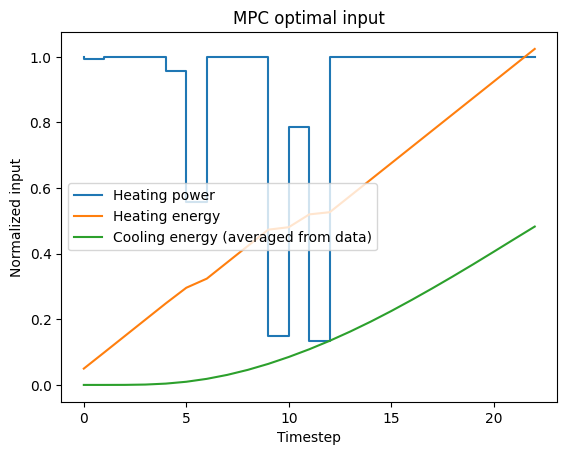

In [174]:
plt.title('MPC optimal input')
plt.step(np.arange(len(Uopt)),Uopt[:,0],label='Heating power')
plt.plot(np.arange(len(Uopt)),Uopt[:,1],label='Heating energy')
plt.plot(np.arange(len(Uopt)),Uopt[:,2],label='Cooling energy (averaged from data)')
plt.xlabel('Timestep')
plt.ylabel('Normalized input')
plt.legend()
plt.show()

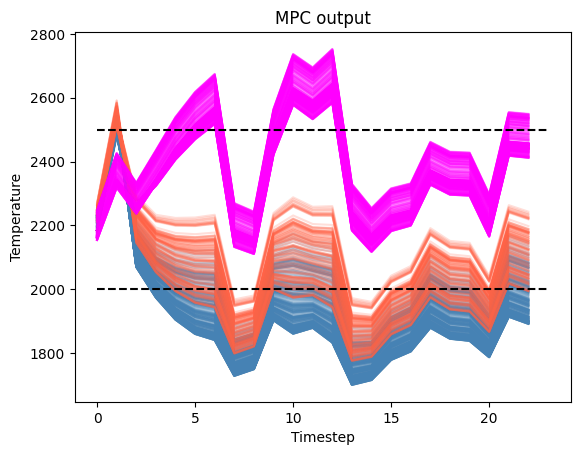

In [175]:
plt.plot(Zpred @ c1_picker.T,color='steelblue',alpha=0.2)
plt.plot(Zpred @ c2_picker.T,color='tomato',alpha=0.2)
plt.plot(Zpred @ sus_picker.T,color='magenta',alpha=0.2)
plt.hlines(c1_target,0,len(Uopt),ls='dashed',color='black')
plt.hlines(-sus_target,0,len(Uopt),ls='dashed',color='black')
plt.xlabel('Timestep')
plt.ylabel('Temperature')
plt.title('MPC output')
plt.show()